In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sacred import Experiment

In [2]:
from models.fftlayer import FFTLayer
from config import initialise
from utils.tupperware import tupperware
from dataloader import get_dataloaders
from utils.ops import rggb_2_rgb, unpixel_shuffle


In [3]:
from SRIL_utils.plot_aux import myim,plot_image_histogram,plot_hist

In [4]:
ex = Experiment("Train",interactive=True)
ex = initialise(ex)

In [5]:
@ex.main
def notebook_main():
    pass

In [6]:
run = ex.run(config_updates={'batch_size': 1,
                            "image_dir":"/mnt/c/dev/lensless/phlatcam/imagenet/",
                            "train_source_list":"/mnt/c/dev/lensless/phlatcam/imagenet/text_files/train_source_imagenet_384_384_Feb_19_debug.txt",
                            },
                            named_configs=['ours_meas_1280_1408'])
args = tupperware(run.config)
args.image_dir = Path(args.image_dir)

WARNING - root - Changed type of config entry "image_dir" from PosixPath to str
WARNING - root - Changed type of config entry "train_source_list" from PosixPath to str
WARNING - Train - No observers have been added to this run
INFO - Train - Running command 'notebook_main'
INFO - Train - Started
INFO - Train - Completed after 0:00:00


In [7]:
args.train_source_list

'/mnt/c/dev/lensless/phlatcam/imagenet/text_files/train_source_imagenet_384_384_Feb_19_debug.txt'

In [8]:
data = get_dataloaders(args, is_local_rank_0=True)

INFO - root - dataset = train Before: len(self.source_paths)=80
INFO - root - dataset = train After: len(self.source_paths)=21
INFO - root - Train Set | Image Dir: /mnt/c/dev/lensless/phlatcam/imagenet
INFO - root - dataset = val Before: len(self.source_paths)=103
INFO - root - dataset = val After: len(self.source_paths)=30
INFO - root - Val Set | Image Dir: /mnt/c/dev/lensless/phlatcam/imagenet
INFO - root - dataset = test Before: len(self.source_paths)=0
INFO - root - dataset = test After: len(self.source_paths)=0
INFO - root - Test Set | Image Dir: /mnt/c/dev/lensless/phlatcam/imagenet
INFO - root - Dataset: phase_mask Len Train: 21 Val: 30  Test: 0


In [9]:
FFT = FFTLayer(args)

In [10]:
FFT

FFTLayer()

In [11]:
#idl =iter(data.train_loader)
idl =iter(data.val_loader)

In [12]:
batch = next(idl)

In [13]:
source, target, filename = batch

In [14]:
source.shape,target.shape,filename

(torch.Size([1, 4, 1280, 1408]),
 torch.Size([1, 3, 384, 384]),
 ('n02980441_2032.png',))

In [28]:
source_vis =  rggb_2_rgb(source[0]).mul(0.5).add(0.5)

In [32]:
source_vis=source_vis / source_vis.max()

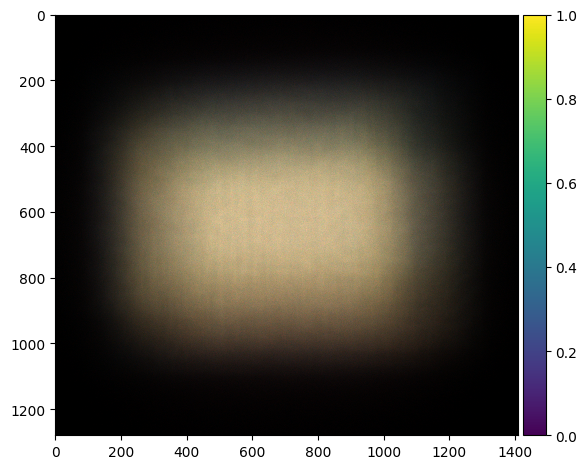

[(<Axes: >, <Axes: >)]

In [33]:
myim(source_vis,torch2np=True,colorbar=True)

In [17]:
fft_output = FFT._forward(source)

In [18]:
fft_output.shape

torch.Size([1, 4, 1280, 1408])

In [19]:
fft_output_vis = (
            rggb_2_rgb(fft_output[0]).mul(0.5).add(0.5)
                )

In [20]:
fft_output_vis.shape

torch.Size([3, 1280, 1408])

In [21]:
fft_output_vis = (fft_output_vis - fft_output_vis.min()) / (
                                fft_output_vis.max() - fft_output_vis.min()
                            )

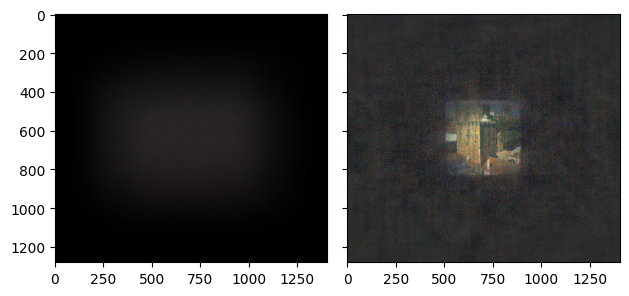

[(<Axes: >, None), (<Axes: >, None)]

In [27]:
myim(source[0,:3]*0.5+0.5,fft_output_vis.detach(),torch2np=True)

In [22]:
fft_output_vis.shape,target.shape

(torch.Size([3, 1280, 1408]), torch.Size([1, 3, 384, 384]))

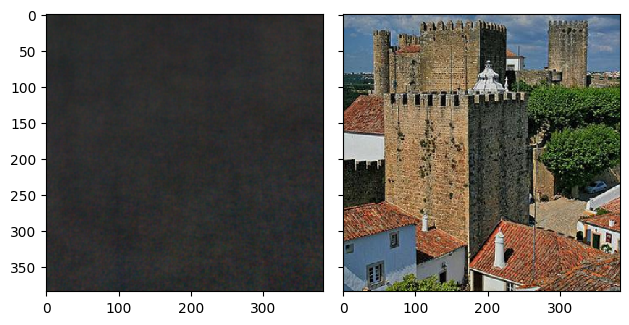

[(<Axes: >, None), (<Axes: >, None)]

In [23]:
myim(fft_output_vis.detach(),target[0]*0.5+0.5,
        torch2np=True)

In [60]:
#cxhxw - > hxwxc 
#fft_output_vis = fft_output_vis.permute(1, 2, 0).cpu().detach().numpy()

In [61]:
#plt.imshow(fft_output_vis)

In [62]:
FFT.wiener_crop.shape

torch.Size([1280, 1408])

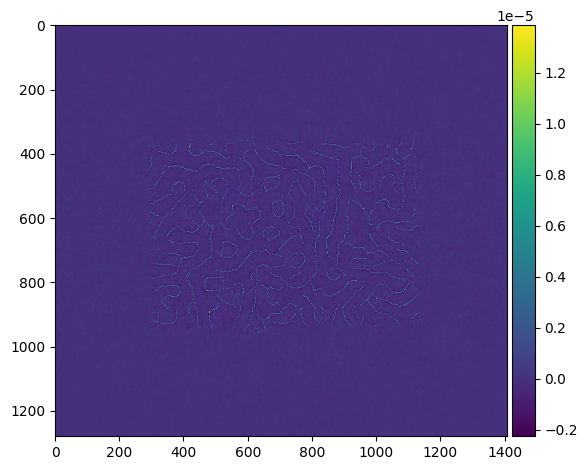

[(<Axes: >, <Axes: >)]

In [35]:
psf = FFT.wiener_crop.detach().cpu().numpy()
myim(psf,colorbar=True)

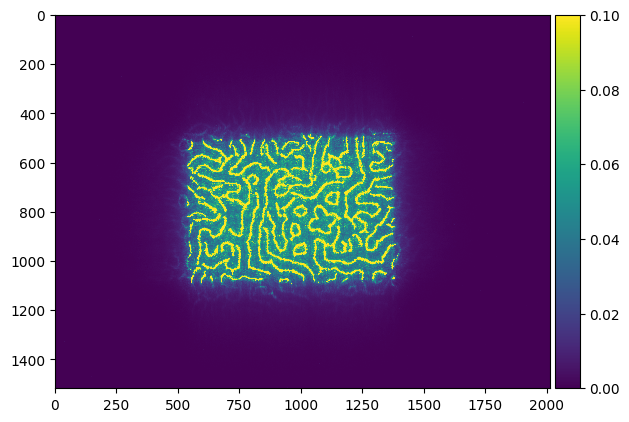

[(<Axes: >, <Axes: >)]

In [36]:
psf = np.load(args.psf_mat)
myim(psf,colorbar=True,global_range=[0,0.1])

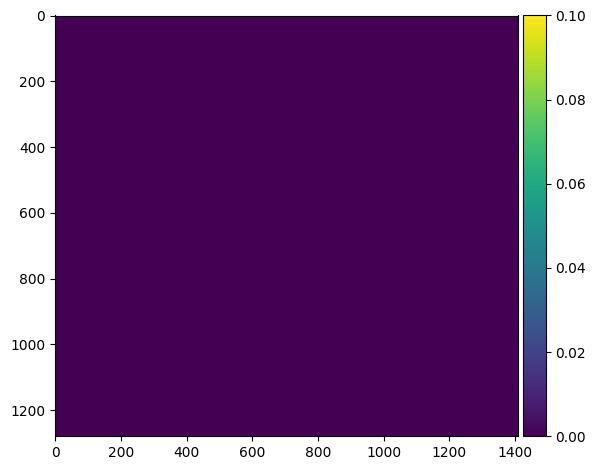

[(<Axes: >, <Axes: >)]

In [68]:
#plt.imshow(psf)
myim(psf,colorbar=True,global_range=[0,0.1])

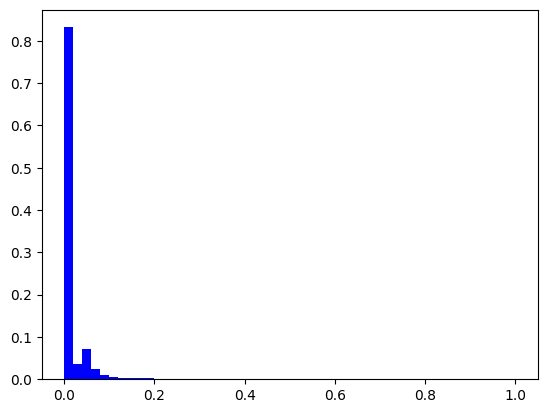

In [37]:
_=plot_hist(psf)


WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011725903..0.22811583].


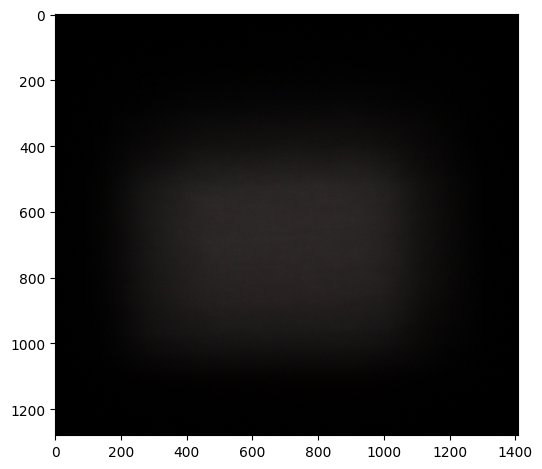

[(<Axes: >, None)]

In [63]:
myim(source[0,:3].detach()*0.5+0.5,torch2np=True)

In [20]:
meas_height = 1518  # original height of meas
meas_width = 2012  # original width of meas
meas_crop_size_x = 1280  # Meas crop. If 0, assume no crop
meas_crop_size_y = 1408
meas_centre_x = 808
meas_centre_y = 965

psf_height = 1280  # fft layer height
psf_width = 1408  # fft layer width
psf_crop_size_x = 1280
psf_crop_size_y = 1408
psf_centre_x = meas_centre_x
psf_centre_y = meas_centre_y

In [10]:
psf_mat = 'data/phase_psf/psf.npy'
psf_tiff = '/mnt/c/dev/lensless/diffuser_data/psf.tiff'

In [24]:
psf = np.array(np.load(psf_mat))
#psf = torch.tensor(np.load(args.psf_mat)).float()

psf_crop_top = psf_centre_x - psf_crop_size_x // 2
psf_crop_bottom = psf_centre_x + psf_crop_size_x // 2
psf_crop_left = psf_centre_y - psf_crop_size_y // 2
psf_crop_right = psf_centre_y + psf_crop_size_y // 2

psf_crop = psf[psf_crop_top:psf_crop_bottom, psf_crop_left:psf_crop_right]

#wiener_crop = get_wiener_matrix(
#    psf_crop, Gamma=args.fft_gamma, centre_roll=False
#    )
psf_phat=psf_crop

In [26]:
psf.shape,psf_crop.shape

((1518, 2012), (1280, 1408))

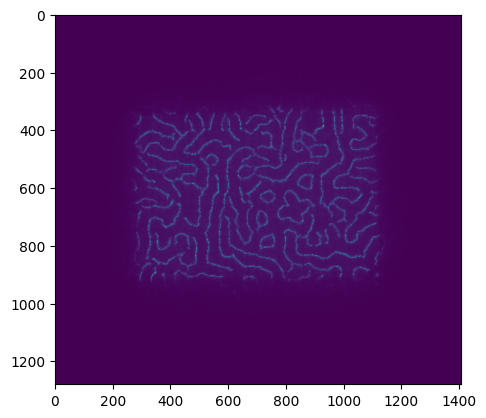

In [25]:
plt.imshow(psf_phat)

In [14]:
psf_pho = np.array(Image.open(psf_tiff))

In [15]:
psf.shape,psf.dtype

((1518, 2012), dtype('float32'))

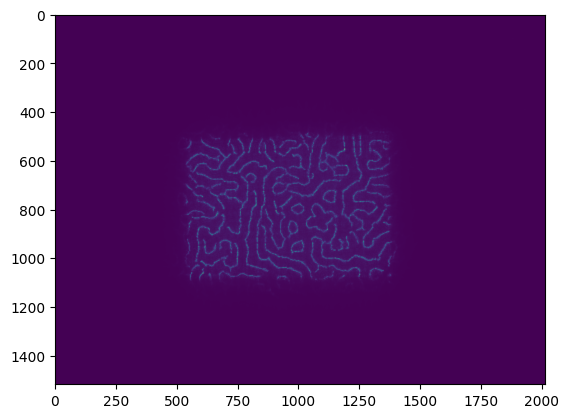

In [8]:
plt.imshow(psf)

In [ ]:
psf_phat.max(),psf_phat.min(),

(np.float32(1.0), np.float32(0.0))

In [16]:
psf_pho.shape,psf_pho.dtype

((1080, 1920, 3), dtype('uint8'))

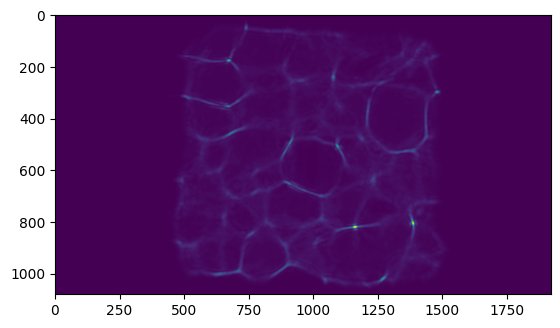

In [19]:
plt.imshow(psf_pho[...,0])